# Chapter 10: Plans Within Plans: Hierarchical Actions and Reusable Skills

A reusable review skill hides several primitive actions behind one name. That abstraction is useful, but it can also hide time. A one-step archive action and a three-step review-release option do not place their continuation at the same discount offset. Nor does beginning an option imply that its termination condition will be reached.

This notebook compares declared options through their reward traces, initiation predicates, completion flags, and deadlines. It does not execute a live skill. It calculates what follows from a finite trace. The changed case interrupts the useful option before its release reward, forcing the report to separate local activity from workflow completion.

**Outcome:** Compute option returns with duration discounting and explicit completion.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For an option of duration d with primitive rewards r_0,...,r_(d-1), its completed value is sum_(t=0)^(d-1) gamma^t r_t + gamma^d V_cont. The continuation discount depends on duration, not on the fact that the option has one convenient label.

The option is executable only when its initiation predicate holds. Its executed prefix is limited by remaining deadline and the declared interruption cap. Continuation value is added only if every primitive step executes and the termination flag is true. An executed prefix may have nonzero reward while completion remains false.

This is a deterministic trace calculation. It does not model a distribution of option durations or an internal stochastic policy. Those would require expected discounted rewards and state-dependent termination probabilities. The finite representation is still useful for catching a common modeling error: assigning the full continuation value to a macro-action that never reaches its promised boundary.

## A calculation you can run

Each option row supplies a name, exact boolean initiation status, primitive rewards, exact boolean termination status, and optional continuation value. Global inputs specify discount, deadline, elapsed start time, and optional interruption cap. Validation rejects invalid counts, nonfinite rewards, and ambiguous truth values.

The function determines the available prefix, sums its discounted rewards, and conditionally adds completion continuation. It reports full duration, executed duration, completion, and continuation discount. The figures compare executed value and primitive-step count; they should not be combined because their units differ. Run the changed interruption case and inspect which reward terms disappeared. A high full-option value is irrelevant if the actual prefix cannot reach it.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 10
inputs = {'discount': 0.9,
 'deadline': 5,
 'options': [{'name': 'review-release',
              'initiation': True,
              'rewards': [-1, -1, 8],
              'terminated': True,
              'continuation_value': 2},
             {'name': 'archive',
              'initiation': True,
              'rewards': [1],
              'terminated': True,
              'continuation_value': 0}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 10: option-duration
Does a reusable skill finish before interruption or the deadline?
Evidence: constructed teaching example

Calculated quantities:
{
  "options": [
    {
      "name": "review-release",
      "duration": 3,
      "initiated": true,
      "executed": 3,
      "complete": true,
      "value": 6.038,
      "continuation_discount": 0.729
    },
    {
      "name": "archive",
      "duration": 1,
      "initiated": true,
      "executed": 1,
      "complete": true,
      "value": 1.0,
      "continuation_discount": 0.9
    }
  ],
  "best_executed_value": "review-release",
  "completed_options": 2
}

Interpretation:
An option receives continuation value only after its declared termination. A deadline or interruption can leave locally useful work without workflow completion.

Assumptions:
- Rewards occur at primitive time offsets beginning at zero.
- Continuation discount uses the full option duration.
- Initiation and termination predicates are declared for this sta

The default review-release value is -1-0.9+0.9^2(8)+0.9^3(2)=6.038. It completes in three steps within the five-step deadline. Archive gives value 1.

The changed interruption permits only two steps of review-release. Its value becomes -1-0.9=-1.9, completion is false, and no continuation is added. Archive still completes and remains worth 1, so it becomes the preferred executed value. The reversal comes from lost access to the option's terminal benefit, not a change in the release payoff.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


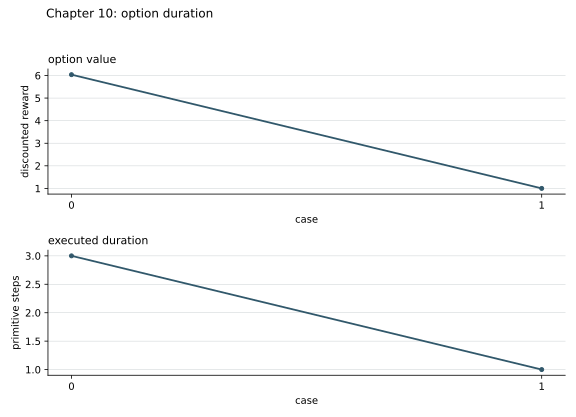

In [3]:
display(SVG(figure_svg(report)))

**Figure 10.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

An option label can conceal an unsafe initiation assumption. If review requires a current document version, a generic initiation flag is insufficient for deployment until that predicate is tied to observed state. Likewise, the returned termination flag is a supplied trace fact, not an automatically verified effect.

Another failure is to discount continuation by one macro step regardless of duration. That exaggerates long options when gamma is below one. The transfer case exposes the difference directly.

An interruption contract should state what remains durable, whether the option can resume, and which action is safe next. This notebook stops at the prefix and does not invent recovery. A partial option can create cost or state change even when its workflow completion flag is false. Preserve that consequence in a larger trace model.

Chapter 10: option-duration
Does a reusable skill finish before interruption or the deadline?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "options": [
    {
      "name": "review-release",
      "duration": 3,
      "initiated": true,
      "executed": 2,
      "complete": false,
      "value": -1.9,
      "continuation_discount": 0
    },
    {
      "name": "archive",
      "duration": 1,
      "initiated": true,
      "executed": 1,
      "complete": true,
      "value": 1.0,
      "continuation_discount": 0.9
    }
  ],
  "best_executed_value": "archive",
  "completed_options": 1
}

Interpretation:
An option receives continuation value only after its declared termination. A deadline or interruption can leave locally useful work without workflow completion.

Assumptions:
- Rewards occur at primitive time offsets beginning at zero.
- Continuation discount uses the full option duration.
- Initiation and termination predicates are declared for this stat

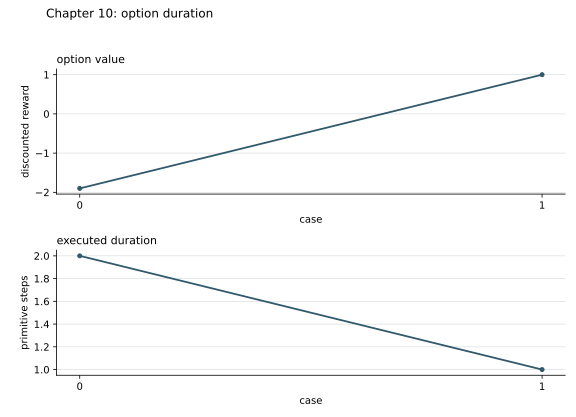

In [4]:
changed_inputs = {'discount': 0.9,
 'deadline': 5,
 'options': [{'name': 'review-release',
              'initiation': True,
              'rewards': [-1, -1, 8],
              'terminated': True,
              'continuation_value': 2},
             {'name': 'archive',
              'initiation': True,
              'rewards': [1],
              'terminated': True,
              'continuation_value': 0}],
 'interrupt_after': 2}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 10.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

In the transfer case, inspect executes two steps with rewards 0 and 4. At gamma=0.5, its local reward is 2 and its continuation contributes 0.5^2(8)=2, for total value 4. The disabled option executes zero steps despite its attractive nominal reward.

For local use, extract primitive duration and reward timing from a compatible declared workflow. Keep initiation, termination, interruption, and deadline conditions explicit. If durations vary, analyze separate traces or extend the model with a documented distribution. Do not replace measured completion with a skill's descriptive name.

In [5]:
transfer_inputs = {'discount': 0.5,
 'deadline': 2,
 'start_time': 0,
 'options': [{'name': 'inspect',
              'initiation': True,
              'rewards': [0, 4],
              'terminated': True,
              'continuation_value': 8},
             {'name': 'disabled',
              'initiation': False,
              'rewards': [9],
              'terminated': True,
              'continuation_value': 0}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 10: option-duration
Does a reusable skill finish before interruption or the deadline?
Evidence: constructed transfer example

Calculated quantities:
{
  "options": [
    {
      "name": "inspect",
      "duration": 2,
      "initiated": true,
      "executed": 2,
      "complete": true,
      "value": 4.0,
      "continuation_discount": 0.25
    },
    {
      "name": "disabled",
      "duration": 1,
      "initiated": false,
      "executed": 0,
      "complete": false,
      "value": 0,
      "continuation_discount": 0
    }
  ],
  "best_executed_value": "inspect",
  "completed_options": 1
}

Interpretation:
An option receives continuation value only after its declared termination. A deadline or interruption can leave locally useful work without workflow completion.

Assumptions:
- Rewards occur at primitive time offsets beginning at zero.
- Continuation discount uses the full option duration.
- Initiation and termination predicates are declared for this state.

Limitations:


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **discount:** Gamma in [0,1].
- **deadline:** Nonnegative integer primitive-step deadline.
- **start_time:** Nonnegative elapsed time, same unit as deadline.
- **interrupt_after:** Optional nonnegative integer executed-step cap for each option.
- **options:** Each option has name,initiation:boolean,rewards:nonempty primitive reward list,terminated:boolean,continuation_value:number.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch10.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 10: option-duration
Does a reusable skill finish before interruption or the deadline?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "options": [
    {
      "name": "inspect",
      "duration": 2,
      "initiated": true,
      "executed": 2,
      "complete": true,
      "value": 4.0,
      "continuation_discount": 0.25
    },
    {
      "name": "disabled",
      "duration": 1,
      "initiated": false,
      "executed": 0,
      "complete": false,
      "value": 0,
      "continuation_discount": 0
    }
  ],
  "best_executed_value": "inspect",
  "completed_options": 1
}

Interpretation:
An option receives continuation value only after its declared termination. A deadline or interruption can leave locally useful work without workflow completion.

Assumptions:
- Rewards occur at primitive time offsets beginning at zero.
- Continuation discount uses the full option duration.
- Initiation and termination predicates are declare

## Questions

1. What is default continuation discount?

2. What is interrupted review-release value?

3. Why is transfer continuation contribution 2 rather than 4?

Answers: [separate solutions](../solutions/ch10.md). Try the calculation before opening them.

## Summary

Options compress plans without erasing duration. Completed continuation is discounted by the number of primitive steps and is withheld when initiation, deadline, interruption, or termination prevents completion. The default favors review-release; interruption reverses that choice; the transfer case checks duration discounting. The result is a finite option-contract analysis, not a proof that a real skill runs reliably or resumes safely.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-10-option-duration`](../skills/maa-10-option-duration/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 10.1

![Equation 10.1](../assets/math/7197ed5ea6f0ca3a60f7.svg)

Equation (10.1) separates where an option may start, how it acts while running, and how it stops.

Start only in `\mathcal{I}_o`; use `\pi_o` for primitive choices; use `\beta_o` to determine termination.

LaTeX source, preserved for inspection:

```latex
o=(\mathcal{I}_o,\pi_o,\beta_o).
\tag{10.1}
```

### Equation 10.2

![Equation 10.2](../assets/math/fce95d2aa964417b0ea0.svg)

Equation (10.2) values rewards inside an option and value remaining after variable-duration completion.

Discount internal primitive rewards, then discount continuation by actual primitive steps used.

LaTeX source, preserved for inspection:

```latex
Q^{\mu}(x,o)=\operatorname E_\mu\!\left[
\sum_{k=0}^{\tau-1}\gamma^k r_{t+k}
+\gamma^\tau V^\mu(x_{t+\tau})\;\middle|\;x_t=x,o_t=o
\right].
\tag{10.2}
```

### Equation 10.3

![Equation 10.3](../assets/math/83bd672b4dcd183bfb16.svg)

Equation (10.3) keeps completion delay separate from total tool cost in parallel workflow.

Take longest dependency chain for time; add all required activity credits for cost.

LaTeX source, preserved for inspection:

```latex
T_{\mathrm{release}}=\max\{2+3+1,\;4\}=6\text{ minutes},
\qquad C_{\mathrm{tools}}=4+7+2+3=16\text{ credits}.
\tag{10.3}
```